# Классификация: SI выше медианы выборки

Цель ноутбука - построить и сравнить несколько моделей бинарной классификации для задачи: превышает ли значение SI медианное значение выборки.

Используются результаты preprocessing:

- SF_ML_data_tree.pkl - набор признаков после удаления константных и высококоррелированных признаков, предназначенный для tree-based моделей;
- SF_ML_data_linear.pkl - набор признаков после дополнительной VIF-редукции, предназначенный для линейных моделей.

При моделировании из признакового пространства исключаются все целевые переменные: IC50, mM, CC50, mM и SI. Это необходимо для предотвращения утечки данных: модель должна обучаться только на исходных молекулярных признаках, то есть RDKit-дескрипторах.

Поскольку порогом является медиана SI, классы ожидаемо близки к сбалансированным. Поэтому основной метрикой выбирается ROC_AUC, а F1, precision, recall, accuracy и PR_AUC используются как дополнительные метрики.


In [ ]:
import os
import joblib
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline, Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    AdaBoostClassifier
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')

In [25]:
RANDOM_STATE = 42
TEST_SIZE = 0.2
N_SPLITS = 5

TARGET_SOURCE = 'SI'
TARGET_NAME = 'SI_gt_median'
TARGET_COLS = ['IC50, mM', 'CC50, mM', 'SI']

MODELS_DIR = 'models'

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 120)

## Загрузка подготовленных данных

In [26]:
def load_dataset(filename):
    return pd.read_pickle(f'{filename}.pkl')


df_tree = load_dataset('SF_ML_data_tree')
df_linear = load_dataset('SF_ML_data_linear')

print('df_tree shape:', df_tree.shape)
print('df_linear shape:', df_linear.shape)

display(df_tree.head())

df_tree shape: (966, 148)
df_linear shape: (966, 100)


,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,MaxPartialCharge,MinPartialCharge,FpDensityMorgan1,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,Ipc,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA7,SlogP_VSA8,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,...,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_Ndealkylation1,fr_Ndealkylation2,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azo,fr_bicyclic,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_ketone,fr_ketone_Topliss,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_piperdine,fr_piperzine,fr_priamide,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea,"IC50, mM","CC50, mM",SI
0,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,0.038844,-0.293526,0.642857,14.822266,9.700470,2.600532,-2.343082,2.644698,-2.322229,5.944519,0.193481,3.150503,1.164038,2.187750e+06,0.000000,0.0,0.0,0.0,0.0,0.0,9.984809,0.0,0.0,0.0,54.384066,74.032366,35.342864,0.000000,0.000000,11.423370,0.0,0.000000,43.480583,105.750639,13.089513,0.00000,0.0,0.000000,0.000000,0.0,24.512883,0.000000,33.495774,105.750639,0.0,0.0,24.72,0.0,0.0,0.0,0.000000,21.659962,24.925325,64.208216,...,0,0,0,0,0,0,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,6.239374,175.482382,28.125000
1,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,0.012887,-0.313407,0.607143,14.975110,9.689226,2.614066,-2.394690,2.658342,-2.444817,5.134527,0.120322,3.150503,1.080362,2.187750e+06,10.633577,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,54.384066,97.951860,12.083682,0.000000,0.000000,0.000000,0.0,10.633577,33.495774,117.834321,13.089513,0.00000,0.0,10.633577,0.000000,0.0,25.173194,0.000000,33.495774,105.750639,0.0,0.0,24.06,0.0,0.0,0.0,0.000000,21.659962,23.919494,77.297729,...,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0.771831,5.402819,7.000000
2,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,0.094802,-0.325573,0.562500,15.353938,9.681293,2.665274,-2.477203,2.679014,-2.565224,5.117187,-0.922902,3.214947,1.219066,8.610751e+06,8.966062,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,41.542423,74.032366,23.671624,53.363882,8.966062,0.000000,0.0,0.000000,33.495774,117.834321,41.280201,0.00000,0.0,0.000000,0.000000,0.0,62.329944,0.000000,33.495774,105.750639,0.0,0.0,0.00,0.0,0.0,0.0,0.000000,21.659962,23.919494,86.263791,...,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,3,0,223.808778,161.142320,0.720000
3,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,0.038844,-0.293526,0.620690,14.821216,9.700497,2.600529,-2.342885,2.644709,-2.322030,5.944502,0.193510,3.179270,1.120513,3.572142e+06,0.000000,0.0,0.0,0.0,0.0,0.0,9.984809,0.0,0.0,0.0,60.804888,74.032366,35.342864,0.000000,0.000000,11.423370,0.0,0.000000,43.480583,112.171461,13.089513,0.00000,0.0,0.000000,0.000000,0.0,24.512883,0.000000,33.495774,112.171461,0.0,0.0,24.72,0.0,0.0,0.0,0.000000,21.659962,24.925325,70.629038,...,0,0,0,0,0,0,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,1.705624,107.855654,63.235294
4,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,0.062897,-0.257239,0.600000,14.831112,9.700386,2.602486,-2.342009,2.64847

## Формирование бинарной целевой переменной и признаков

Порог классификации задаётся как медиана SI по подготовленной выборке. Положительный класс 1 означает, что значение SI выше медианы выборки.


In [27]:
THRESHOLD = df_tree[TARGET_SOURCE].median()

print('Порог SI median:', THRESHOLD)


def split_features_and_target(df):
    X = df[[col for col in df.columns if col not in TARGET_COLS]].copy()
    y = (df[TARGET_SOURCE] > THRESHOLD).astype(int).copy()
    return X, y


X_tree, y_tree = split_features_and_target(df_tree)
X_linear, y_linear = split_features_and_target(df_linear)

assert y_tree.equals(y_linear), 'Целевая переменная в df_tree и df_linear отличается.'
assert X_tree.index.equals(y_tree.index), 'Индексы X_tree и y_tree не совпадают.'
assert X_linear.index.equals(y_linear.index), 'Индексы X_linear и y_linear не совпадают.'
assert X_tree.index.equals(X_linear.index), 'Индексы X_tree и X_linear не совпадают.'

y = y_tree.copy()

print('X_tree:', X_tree.shape)
print('X_linear:', X_linear.shape)
print('y:', y.shape)

display(
    y.value_counts()
     .rename_axis('class')
     .reset_index(name='count')
     .assign(share=lambda x: x['count'] / x['count'].sum())
)

Порог SI median: 3.9133507853403136
X_tree: (966, 145)
X_linear: (966, 97)
y: (966,)


,class,count,share
0,1,483,0.5
1,0,483,0.5


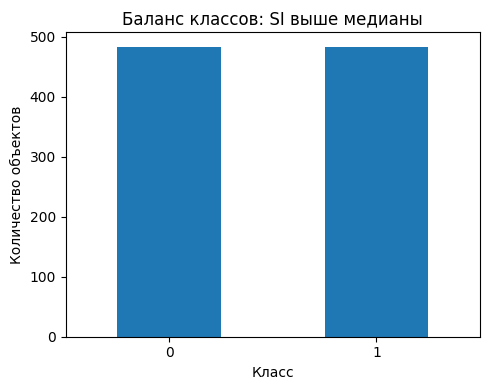

In [28]:
plt.figure(figsize=(5, 4))
y.value_counts().sort_index().plot(kind='bar')
plt.title('Баланс классов: SI выше медианы')
plt.xlabel('Класс')
plt.ylabel('Количество объектов')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Баланс классов

Целевая переменная сформирована как индикатор того, превышает ли SI медианное значение выборки. Так как порогом является медиана, классы должны быть близки к сбалансированным: количество объектов классов 0 и 1 ожидаемо почти одинаковое.

Такой баланс удобен для моделирования: accuracy можно интерпретировать напрямую, balanced_accuracy близка к обычной accuracy, а precision, recall и F1 не искажаются доминированием одного класса. Поэтому специальные методы борьбы с дисбалансом, такие как oversampling или undersampling, для этой задачи обычно не требуются.

Для оценки качества моделей всё равно используются несколько метрик: accuracy, balanced_accuracy, F1, ROC_AUC и PR_AUC. Основной метрикой выбрана ROC_AUC, так как она оценивает способность модели ранжировать объекты по вероятности принадлежности к положительному классу независимо от конкретного порога классификации.


## Разделение данных на train и test выборки

Разделение выполняется один раз и одинаково для X_tree и X_linear. Для классификации используется stratify=y, чтобы сохранить баланс классов в train и test.

In [29]:
train_idx, test_idx = train_test_split(
    np.arange(len(y)),
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

X_tree_train = X_tree.iloc[train_idx].copy()
X_tree_test = X_tree.iloc[test_idx].copy()

X_linear_train = X_linear.iloc[train_idx].copy()
X_linear_test = X_linear.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

print('X_tree_train:', X_tree_train.shape)
print('X_tree_test:', X_tree_test.shape)
print('X_linear_train:', X_linear_train.shape)
print('X_linear_test:', X_linear_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

print('Баланс классов train:')
print(y_train.value_counts(normalize=True).sort_index())

print('Баланс классов test:')
print(y_test.value_counts(normalize=True).sort_index())

X_tree_train: (772, 145)
X_tree_test: (194, 145)
X_linear_train: (772, 97)
X_linear_test: (194, 97)
y_train: (772,)
y_test: (194,)
Баланс классов train:
SI
0    0.5
1    0.5
Name: proportion, dtype: float64
Баланс классов test:
SI
0    0.5
1    0.5
Name: proportion, dtype: float64


## Метрики качества

Основная метрика - ROC_AUC, так как она оценивает качество ранжирования объектов по вероятности положительного класса и не зависит от конкретного порога классификации.

Дополнительно рассчитываются accuracy, balanced_accuracy, precision, recall, F1 и PR_AUC.

In [30]:
def get_positive_scores(model, X):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, 'decision_function'):
        return model.decision_function(X)
    return model.predict(X)


def classification_metrics(y_true, y_pred, y_score):
    return {'accuracy': accuracy_score(y_true, y_pred),
            'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'recall': recall_score(y_true, y_pred, zero_division=0),
            'f1': f1_score(y_true, y_pred, zero_division=0),
            'roc_auc': roc_auc_score(y_true, y_score),
            'pr_auc': average_precision_score(y_true, y_score)}


def evaluate_classifier(model, X_train, X_test, y_train, y_test, refit=True):
    if refit:
        model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_score = get_positive_scores(model, X_test)

    metrics = classification_metrics(y_test, y_pred, y_score)

    return metrics, y_pred, y_score

## Базовые модели

Используются две группы моделей: линейные модели обучаются на X_linear, где дополнительно снижена мультиколлинеарность с помощью VIF-редукции, а tree-based модели обучаются на X_tree, где сохранено больше признаков.

In [31]:
linear_models = {'Dummy_most_frequent': DummyClassifier(strategy='most_frequent'),
                 'LogisticRegression_L2': make_pipeline(StandardScaler(),
                                                        LogisticRegression(penalty='l2', C=1.0, max_iter=5000, 
                                                                           class_weight='balanced', random_state=RANDOM_STATE)),

                 'LogisticRegression_L1': make_pipeline(StandardScaler(),
                                                        LogisticRegression(penalty='l1', solver='liblinear', C=1.0,
                                                                           max_iter=5000, class_weight='balanced', random_state=RANDOM_STATE)),

                 'LinearSVC': make_pipeline(StandardScaler(),
                                            LinearSVC(C=1.0, class_weight='balanced', random_state=RANDOM_STATE, max_iter=10000)),

                 'SVC_rbf': make_pipeline(StandardScaler(),
                                          SVC(kernel='rbf', C=3.0, gamma='scale', class_weight='balanced', random_state=RANDOM_STATE))}

tree_models = {'RandomForest': RandomForestClassifier(n_estimators=500, max_depth=None, min_samples_leaf=2,
                                                      class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1),
    
               'ExtraTrees': ExtraTreesClassifier(n_estimators=500, max_depth=None, min_samples_leaf=2,
                                                  class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1),

               'GradientBoosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
               
               'HistGBM': HistGradientBoostingClassifier(random_state=RANDOM_STATE),
               
               'AdaBoost': AdaBoostClassifier(random_state=RANDOM_STATE),
               
               'XGBoost': XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8, 
                                        colsample_bytree=0.8, eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=1),
                
               'LightGBM': LGBMClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8,
                                          colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=1, verbose=-1)}

## Кросс-валидация базовых моделей

In [32]:
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

scoring = {'roc_auc': 'roc_auc',
           'pr_auc': 'average_precision',
           'f1': 'f1',
           'accuracy': 'accuracy',
           'balanced_accuracy': 'balanced_accuracy'}


def get_cv_row(model_name, model, X_train, y_train, feature_set_name):
    scores = cross_validate(model,
                            X_train,
                            y_train,
                            cv=cv,
                            scoring=scoring,
                            n_jobs=4,
                            return_train_score=True)

    return {'model': model_name,
            'feature_set': feature_set_name,
            'cv_ROC_AUC_mean': scores['test_roc_auc'].mean(),
            'cv_ROC_AUC_std': scores['test_roc_auc'].std(),
            'cv_PR_AUC_mean': scores['test_pr_auc'].mean(),
            'cv_F1_mean': scores['test_f1'].mean(),
            'cv_accuracy_mean': scores['test_accuracy'].mean(),
            'cv_balanced_accuracy_mean': scores['test_balanced_accuracy'].mean(),
            'train_ROC_AUC_mean': scores['train_roc_auc'].mean(),
            'train_F1_mean': scores['train_f1'].mean()}


def run_cv_for_group(models, X_train, y_train, feature_set_name):
    return [get_cv_row(model_name, model, X_train, y_train, feature_set_name)
            for model_name, model in models.items()]


cv_rows = run_cv_for_group(linear_models, X_linear_train, y_train, 'X_linear')\
        + run_cv_for_group(tree_models, X_tree_train, y_train, 'X_tree')


cv_results = pd.DataFrame(cv_rows)\
               .sort_values('cv_ROC_AUC_mean', ascending=False)\
               .reset_index(drop=True)

cv_results['overfit_gap_ROC_AUC'] = cv_results['train_ROC_AUC_mean'] - cv_results['cv_ROC_AUC_mean']

display(cv_results.round(4))

,model,feature_set,cv_ROC_AUC_mean,cv_ROC_AUC_std,cv_PR_AUC_mean,cv_F1_mean,cv_accuracy_mean,cv_balanced_accuracy_mean,train_ROC_AUC_mean,train_F1_mean,overfit_gap_ROC_AUC
0,SVC_rbf,X_linear,0.7159,0.0393,0.7143,0.6486,0.6555,0.6554,0.9224,0.8379,0.2065
1,RandomForest,X_tree,0.7143,0.0315,0.7221,0.6564,0.6594,0.6594,0.9890,0.9555,0.2748
2,XGBoost,X_tree,0.7100,0.0388,0.7133,0.6434,0.6478,0.6478,0.9839,0.9373,0.2739
3,ExtraTrees,X_tree,0.7083,0.0322,0.7130,0.6631,0.6620,0.6620,0.9901,0.9497,0.2817
4,LightGBM,X_tree,0.6997,0.0339,0.7008,0.6561,0.6517,0.6516,0.9901,0.9525,0.2904
5,HistGBM,X_tree,0.6947,0.0403,0.6906,0.6358,0.6348,0.6348,0.9959,0.9598,0.3011
6,GradientBoosting,X_tree,0.6942,0.0266,0.6842,0.6364,0.6425,0.6426,0.9725,0.9208,0.2782
7,AdaBoost,X_tree,0.6932,0.0419,0.6909,0.6421,0.6502,0.6503,0.7892,0.7129,0.0960
8,LogisticRegression_L1,X_linear,0.6913,0.0310,0.6920,0.6355,0.6400,0.6399,0.8146,0.7267,0.1233
9,LogisticRegression_L2,X_linear,0.6898,0.0325,0.6818,0.6442,0.6439,0.6439,0.8181,0.7327,0.1283


## Оценка базовых моделей на тестовой выборке

In [33]:
fitted_baseline = {}


def get_test_result_row(model_name, model, feature_set_name, X_train, X_test, refit=True):
    metrics, y_pred, y_score = evaluate_classifier(model,
                                                   X_train,
                                                   X_test,
                                                   y_train,
                                                   y_test,
                                                   refit=refit)

    if refit:
        fitted_baseline[model_name] = model

    return {'model': model_name,
            'feature_set': feature_set_name,
            **metrics}, y_pred, y_score


model_groups = [(linear_models, 'X_linear', X_linear_train, X_linear_test),
                (tree_models, 'X_tree', X_tree_train, X_tree_test)]

test_outputs = [get_test_result_row(model_name, model, feature_set_name, X_train, X_test)
                for models, feature_set_name, X_train, X_test in model_groups
                for model_name, model in models.items()]

test_rows = [row for row, _, _ in test_outputs]

test_results = pd.DataFrame(test_rows)\
                 .sort_values('roc_auc', ascending=False)\
                 .reset_index(drop=True)

display(test_results.round(4))

,model,feature_set,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
0,SVC_rbf,X_linear,0.6856,0.6856,0.6837,0.6907,0.6872,0.7514,0.7707
1,AdaBoost,X_tree,0.6392,0.6392,0.6588,0.5773,0.6154,0.7241,0.7310
2,GradientBoosting,X_tree,0.6856,0.6856,0.6957,0.6598,0.6772,0.7161,0.7086
3,RandomForest,X_tree,0.6443,0.6443,0.6522,0.6186,0.6349,0.7084,0.7302
4,XGBoost,X_tree,0.6443,0.6443,0.6522,0.6186,0.6349,0.7002,0.7088
5,ExtraTrees,X_tree,0.6289,0.6289,0.6344,0.6082,0.6211,0.6970,0.7171
6,LightGBM,X_tree,0.6340,0.6340,0.6383,0.6186,0.6283,0.6853,0.6815
7,LogisticRegression_L1,X_linear,0.6649,0.6649,0.6600,0.6804,0.6701,0.6776,0.6185
8,LinearSVC,X_linear,0.6546,0.6546,0.6500,0.6701,0.6599,0.6725,0.6255
9,LogisticRegression_L2,X_linear,0.6598,0.6598,0.6566,0.6701,0.6633,0.6722,0.6164


## График сравнения моделей

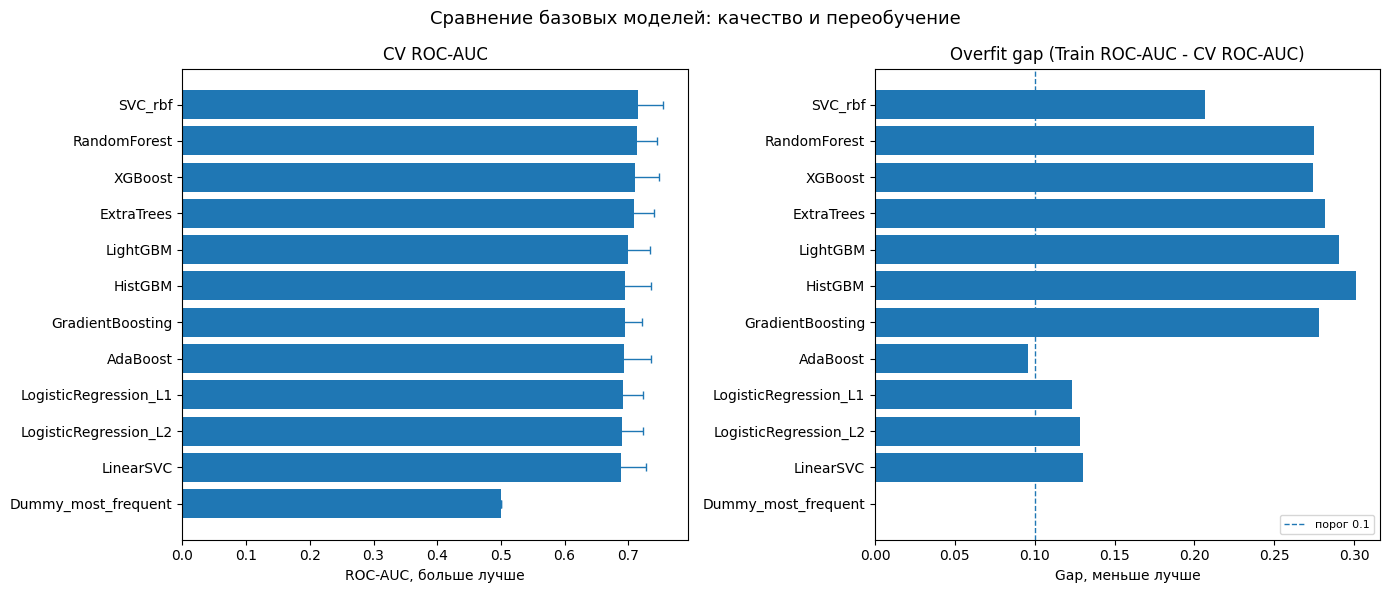

In [34]:
plot_df = cv_results.sort_values('cv_ROC_AUC_mean', ascending=True)
order = plot_df['model'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(plot_df['model'], plot_df['cv_ROC_AUC_mean'])
axes[0].errorbar(
    plot_df['cv_ROC_AUC_mean'],
    plot_df['model'],
    xerr=plot_df['cv_ROC_AUC_std'],
    fmt='none',
    capsize=3,
    linewidth=1
)
axes[0].set_title('CV ROC-AUC')
axes[0].set_xlabel('ROC-AUC, больше лучше')

gap_df = cv_results.set_index('model').reindex(order).reset_index()

axes[1].barh(gap_df['model'], gap_df['overfit_gap_ROC_AUC'])
axes[1].axvline(0.1, linestyle='--', linewidth=1, label='порог 0.1')
axes[1].set_title('Overfit gap (Train ROC-AUC - CV ROC-AUC)')
axes[1].set_xlabel('Gap, меньше лучше')
axes[1].legend(fontsize=8, loc='lower right')

plt.suptitle('Сравнение базовых моделей: качество и переобучение', fontsize=13)
plt.tight_layout()
plt.show()

## Выбор моделей для подбора гиперпараметров

Для задачи классификации SI выше медианы результаты оказались менее сильными, чем для задач IC50 и CC50 выше медианы. Это ожидаемо, поскольку SI является производной величиной CC50 / IC50 и может иметь более сложную и шумную связь с RDKit-дескрипторами.

На кросс-валидации лучший средний ROC_AUC показала модель SVC_rbf на X_linear: cv_ROC_AUC = 0.7159. Близкие результаты также получили RandomForest, XGBoost и ExtraTrees. На тестовой выборке SVC_rbf также оказалась лучшей baseline-моделью: ROC_AUC = 0.7514, PR_AUC = 0.7707, accuracy = 0.6856 и F1 = 0.6872.

Tree-based модели показали умеренное качество, но при этом имели выраженный overfit_gap_ROC_AUC. У RandomForest, XGBoost, ExtraTrees, LightGBM и HistGBM train ROC_AUC был близок к 0.98-1.00, тогда как CV ROC_AUC находился примерно на уровне 0.69-0.71. Это указывает на заметный риск переобучения.

AdaBoost показал самый низкий overfit_gap_ROC_AUC среди реальных моделей, однако его ROC_AUC, PR_AUC и F1 уступают лучшим моделям, прежде всего SVC_rbf и нескольким tree-based алгоритмам. Поэтому AdaBoost оставлен как устойчивый baseline, но не рассматривается как основной кандидат для тюнинга.

Для подбора гиперпараметров отобраны LogisticRegression, SVC_rbf, RandomForest, ExtraTrees, GradientBoosting, HistGBM, XGBoost и LightGBM. SVC_rbf включён как лучшая baseline-модель по CV и test ROC_AUC, LogisticRegression - как регуляризованная линейная модель для сравнения, а tree-based модели оставлены как альтернативные нелинейные алгоритмы на X_tree.

LinearSVC, AdaBoost и Dummy_most_frequent не тюнингуются. Dummy_most_frequent используется только как наивный baseline, LinearSVC уступает SVC_rbf, а AdaBoost, несмотря на низкое переобучение, уступает лучшим моделям по совокупности ROC_AUC, PR_AUC и F1.

## Настройка гиперпараметров

Тюнинг выполняется по ROC_AUC, так как это основная метрика для данной классификационной задачи.

In [35]:
tuning_configs = {
    'LogisticRegression_tuned': {'feature_set': 'X_linear',
                                 'X_train': X_linear_train,
                                 'X_test': X_linear_test,
                                 'estimator': make_pipeline(StandardScaler(),
                                                            LogisticRegression(max_iter=5000,
                                                                               class_weight='balanced',
                                                                               random_state=RANDOM_STATE)),
                                 'params': {'logisticregression__penalty': ['l1', 'l2'],
                                            'logisticregression__C':       np.logspace(-3, 2, 30),
                                            'logisticregression__solver':  ['liblinear']}},

    'SVC_tuned':                {'feature_set': 'X_linear',
                                 'X_train': X_linear_train,
                                 'X_test': X_linear_test,
                                 'estimator': make_pipeline(StandardScaler(),
                                                            SVC(kernel='rbf',
                                                                class_weight='balanced',
                                                                random_state=RANDOM_STATE)),
                                 'params': {'svc__C':     [0.3, 1, 3, 10, 30, 100],
                                            'svc__gamma': ['scale', 0.0003, 0.001, 0.003, 0.01, 0.03]}},

    'RandomForest_tuned':       {'feature_set': 'X_tree',
                                 'X_train': X_tree_train,
                                 'X_test': X_tree_test,
                                 'estimator': RandomForestClassifier(random_state=RANDOM_STATE,
                                                                     class_weight='balanced',
                                                                     n_jobs=1),
                                 'params': {'n_estimators':     [300, 500, 800],
                                            'max_depth':        [None, 4, 6, 8, 12],
                                            'min_samples_leaf': [1, 2, 4, 8],
                                            'max_features':     ['sqrt', 0.3, 0.5, 0.7]}},

    'ExtraTrees_tuned':         {'feature_set': 'X_tree',
                                 'X_train': X_tree_train,
                                 'X_test': X_tree_test,
                                 'estimator': ExtraTreesClassifier(random_state=RANDOM_STATE,
                                                                   class_weight='balanced',
                                                                   n_jobs=1),
                                 'params': {'n_estimators':     [300, 500, 800],
                                            'max_depth':        [None, 4, 6, 8, 12],
                                            'min_samples_leaf': [1, 2, 4, 8],
                                            'max_features':     ['sqrt', 0.3, 0.5, 0.7]}},

    'XGBoost_tuned':            {'feature_set': 'X_tree',
                                 'X_train': X_tree_train,
                                 'X_test': X_tree_test,
                                 'estimator': XGBClassifier(eval_metric='logloss',
                                                            random_state=RANDOM_STATE,
                                                            n_jobs=1),
                                 'params': {'n_estimators':     [100, 200, 300, 500],
                                            'max_depth':        [2, 3, 4, 5],
                                            'learning_rate':    [0.01, 0.03, 0.05, 0.1],
                                            'subsample':        [0.7, 0.85, 1.0],
                                            'colsample_bytree': [0.6, 0.8, 1.0],
                                            'reg_alpha':        [0.0, 0.1, 0.5],
                                            'reg_lambda':       [1.0, 2.0, 5.0]}},
    
    'GradientBoosting_tuned':   {'feature_set': 'X_tree',
                                 'X_train': X_tree_train,
                                 'X_test': X_tree_test,
                                 'estimator': GradientBoostingClassifier(random_state=RANDOM_STATE),
                                 'params': {'n_estimators':     [100, 200, 300, 500],
                                            'learning_rate':    [0.01, 0.03, 0.05, 0.1],
                                            'max_depth':        [2, 3, 4],
                                            'min_samples_leaf': [5, 10, 20, 30],
                                            'subsample':        [0.7, 0.85, 1.0],
                                            'max_features':     ['sqrt', 0.5, 0.8]}},

    'HistGBM_tuned':            {'feature_set': 'X_tree',
                                 'X_train': X_tree_train,
                                 'X_test': X_tree_test,
                                 'estimator': HistGradientBoostingClassifier(random_state=RANDOM_STATE),
                                 'params': {'max_iter':          [100, 200, 300, 500],
                                            'learning_rate':     [0.01, 0.03, 0.05, 0.1],
                                            'max_depth':         [None, 3, 5, 8],
                                            'min_samples_leaf':  [10, 20, 30, 50],
                                            'l2_regularization': [0.0, 0.01, 0.1, 1.0]}},

    'LightGBM_tuned':           {'feature_set': 'X_tree',
                                 'X_train': X_tree_train,
                                 'X_test': X_tree_test,
                                 'estimator': LGBMClassifier(random_state=RANDOM_STATE,
                                                             n_jobs=1,
                                                             verbose=-1),
                                 'params': {'n_estimators':      [100, 200, 300, 500],
                                            'max_depth':         [3, 4, 5],
                                            'learning_rate':     [0.01, 0.03, 0.05, 0.1],
                                            'subsample':         [0.7, 0.85],
                                            'colsample_bytree':  [0.6, 0.8],
                                            'reg_alpha':         [0.0, 0.1, 0.5, 1.0],
                                            'reg_lambda':        [1.0, 2.0, 5.0],
                                            'num_leaves':        [7, 15, 31],
                                            'min_child_samples': [10, 20, 50]}}
}

In [36]:
tuned_rows_cv = {}
best_models = {}

N_ITER_MAP = {
    'LogisticRegression_tuned': 30,
    'SVC_tuned':                30,
    'RandomForest_tuned':       50,
    'ExtraTrees_tuned':         50,
    'GradientBoosting_tuned':   40,
    'HistGBM_tuned':            50,
    'XGBoost_tuned':            40,
    'LightGBM_tuned':           30,
}

for model_name, config in tuning_configs.items():
    search = RandomizedSearchCV(estimator=config['estimator'],
                                param_distributions=config['params'],
                                n_iter=N_ITER_MAP[model_name],
                                scoring='roc_auc',
                                cv=cv,
                                random_state=RANDOM_STATE,
                                n_jobs=4,
                                verbose=1)

    search.fit(config['X_train'], y_train)

    best_models[model_name] = search.best_estimator_

    tuned_rows_cv[model_name] = {'model': model_name,
                                 'feature_set': config['feature_set'],
                                 'best_cv_ROC_AUC': search.best_score_,
                                 'best_params': search.best_params_}


tuning_results = pd.DataFrame(tuned_rows_cv.values())\
                   .sort_values('best_cv_ROC_AUC', ascending=False)\
                   .reset_index(drop=True)

display(tuning_results)


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits


,model,feature_set,best_cv_ROC_AUC,best_params
0,ExtraTrees_tuned,X_tree,0.727623,"{'n_estimators': 800, 'min_samples_leaf': 4, '..."
1,RandomForest_tuned,X_tree,0.722699,"{'n_estimators': 300, 'min_samples_leaf': 8, '..."
2,GradientBoosting_tuned,X_tree,0.718648,"{'subsample': 1.0, 'n_estimators': 100, 'min_s..."
3,LightGBM_tuned,X_tree,0.716414,"{'subsample': 0.7, 'reg_lambda': 5.0, 'reg_alp..."
4,SVC_tuned,X_linear,0.715904,"{'svc__gamma': 'scale', 'svc__C': 3}"
5,XGBoost_tuned,X_tree,0.714194,"{'subsample': 0.85, 'reg_lambda': 5.0, 'reg_al..."
6,HistGBM_tuned,X_tree,0.713957,"{'min_samples_leaf': 30, 'max_iter': 100, 'max..."
7,LogisticRegression_tuned,X_linear,0.696062,"{'logisticregression__solver': 'liblinear', 'l..."


## Сравнение baseline и tuned моделей на test

In [37]:
tuned_test_outputs = [get_test_result_row(model_name=model_name,
                                          model=model,
                                          feature_set_name=tuning_configs[model_name]['feature_set'],
                                          X_train=tuning_configs[model_name]['X_train'],
                                          X_test=tuning_configs[model_name]['X_test'],
                                          refit=False)
                      for model_name, model in best_models.items()]

tuned_test_rows = [row for row, _, _ in tuned_test_outputs]

all_results = pd.concat([test_results.assign(stage='baseline'),
                         pd.DataFrame(tuned_test_rows).assign(stage='tuned')], ignore_index=True)\
                .sort_values('roc_auc', ascending=False)\
                .reset_index(drop=True)

display(all_results.round(4))

,model,feature_set,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,stage
0,ExtraTrees_tuned,X_tree,0.6907,0.6907,0.7342,0.5979,0.6591,0.7543,0.7515,tuned
1,SVC_rbf,X_linear,0.6856,0.6856,0.6837,0.6907,0.6872,0.7514,0.7707,baseline
2,SVC_tuned,X_linear,0.6856,0.6856,0.6837,0.6907,0.6872,0.7514,0.7707,tuned
3,RandomForest_tuned,X_tree,0.6701,0.6701,0.7200,0.5567,0.6279,0.7476,0.7517,tuned
4,GradientBoosting_tuned,X_tree,0.6804,0.6804,0.7536,0.5361,0.6265,0.7330,0.7554,tuned
5,AdaBoost,X_tree,0.6392,0.6392,0.6588,0.5773,0.6154,0.7241,0.7310,baseline
6,LightGBM_tuned,X_tree,0.6649,0.6649,0.7162,0.5464,0.6199,0.7178,0.7371,tuned
7,HistGBM_tuned,X_tree,0.6753,0.6753,0.6848,0.6495,0.6667,0.7171,0.7306,tuned
8,GradientBoosting,X_tree,0.6856,0.6856,0.6957,0.6598,0.6772,0.7161,0.7086,baseline
9,RandomForest,X_tree,0.6443,0.6443,0.6522,0.6186,0.6349,0.7084,0.7302,baseline


## Выбор лучшей модели

Финальная модель выбирается по ROC_AUC на тестовой выборке. F1 и PR_AUC анализируются дополнительно, так как они зависят от баланса классов и выбранного порога классификации.

In [38]:
best_row = all_results.iloc[0]
best_model_name = best_row['model']
best_stage = best_row['stage']
best_feature_set = best_row['feature_set']

if best_feature_set == 'X_linear':
    X_best_train = X_linear_train
    X_best_test = X_linear_test
else:
    X_best_train = X_tree_train
    X_best_test = X_tree_test

if best_stage == 'tuned':
    best_model = best_models[best_model_name]
else:
    if best_feature_set == 'X_linear':
        best_model = fitted_baseline[best_model_name]
    else:
        best_model = fitted_baseline[best_model_name]

best_pred = best_model.predict(X_best_test)
best_score = get_positive_scores(best_model, X_best_test)

print('Лучшая модель:', best_model_name)
print('Стадия:', best_stage)
print('Набор признаков:', best_feature_set)

display(best_row.to_frame().T.round(4))

Лучшая модель: ExtraTrees_tuned
Стадия: tuned
Набор признаков: X_tree


,model,feature_set,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,stage
0,ExtraTrees_tuned,X_tree,0.690722,0.690722,0.734177,0.597938,0.659091,0.754278,0.751528,tuned


## Диагностика финальной модели

In [39]:
cm_df = pd.DataFrame(confusion_matrix(y_test, best_pred),
                     index=['true_0', 'true_1'],
                     columns=['pred_0', 'pred_1'])

display(cm_df)

print(classification_report(y_test, best_pred, digits=4))

,pred_0,pred_1
true_0,76,21
true_1,39,58


              precision    recall  f1-score   support

           0     0.6609    0.7835    0.7170        97
           1     0.7342    0.5979    0.6591        97

    accuracy                         0.6907       194
   macro avg     0.6975    0.6907    0.6880       194
weighted avg     0.6975    0.6907    0.6880       194



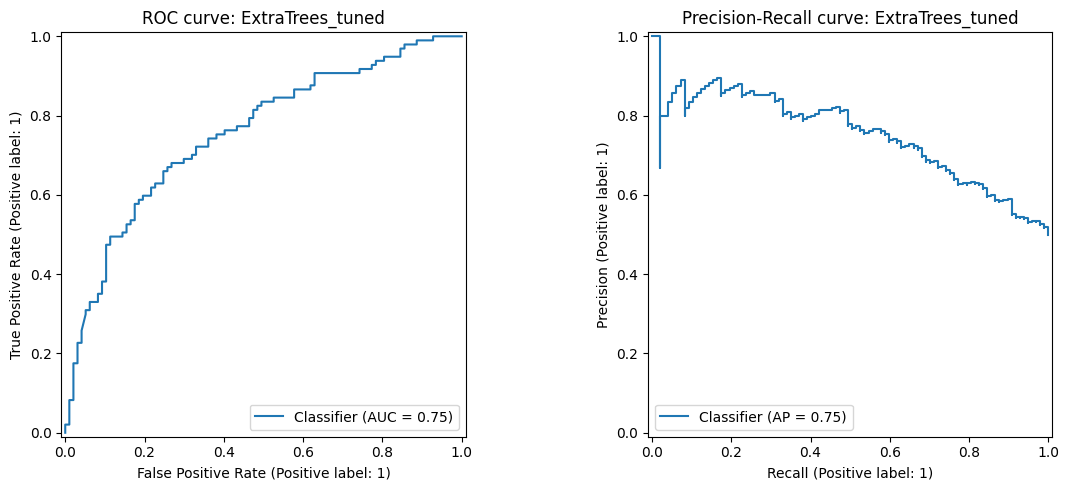

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(y_test, best_score, ax=axes[0])
axes[0].set_title(f'ROC curve: {best_model_name}')

PrecisionRecallDisplay.from_predictions(y_test, best_score, ax=axes[1])
axes[1].set_title(f'Precision-Recall curve: {best_model_name}')

plt.tight_layout()
plt.show()

### Диагностика финальной модели

По итоговой таблице лучшей моделью по основной метрике ROC_AUC стала ExtraTrees_tuned. На тестовой выборке она получила ROC_AUC = 0.7543 и PR_AUC = 0.7515. По сравнению с baseline ExtraTrees качество заметно улучшилось: ROC_AUC вырос с 0.6970 до 0.7543, а PR_AUC - с 0.7171 до 0.7515.

При этом преимущество ExtraTrees_tuned над baseline SVC_rbf по ROC_AUC минимальное: 0.7543 против 0.7514. Кроме того, SVC_rbf показывает более высокие PR_AUC и F1: PR_AUC = 0.7707 и F1 = 0.6872 против PR_AUC = 0.7515 и F1 = 0.6591 у ExtraTrees_tuned. Поэтому ExtraTrees_tuned является лучшей моделью строго по выбранной основной метрике ROC_AUC, но SVC_rbf остаётся сильной альтернативой, если важнее PR_AUC или качество при стандартном пороге 0.5.

Матрица ошибок финальной модели показывает, что модель лучше распознаёт класс 0, чем класс 1: 76 объектов класса 0 классифицированы верно, а 58 объектов класса 1 классифицированы верно. Ошибки распределены не полностью симметрично: 21 объект класса 0 ошибочно отнесён к классу 1, а 39 объектов класса 1 ошибочно отнесены к классу 0. Для класса 1 precision = 0.7342, recall = 0.5979, F1 = 0.6591.

Таким образом, ExtraTrees_tuned корректно выбрана как финальная модель по ROC_AUC, однако для практического применения стоит дополнительно рассмотреть настройку порога классификации. Это может улучшить recall и F1 для положительного класса без обязательной смены модели.

## Важность признаков

Для tree-based моделей используется встроенная feature_importances_. Для линейных моделей используется абсолютное значение коэффициентов. Интерпретация признаков является вспомогательной и требует осторожности.

,feature,importance
0,SMR_VSA4,0.027557
1,SMR_VSA7,0.024683
2,fr_Imine,0.023990
3,FractionCSP3,0.023075
4,NumAliphaticCarbocycles,0.020423
5,NumSaturatedHeterocycles,0.019673
6,NumAliphaticHeterocycles,0.018790
7,SlogP_VSA4,0.016852
8,BCUT2D_LOGPHI,0.016804
9,MaxAbsEStateIndex,0.016156


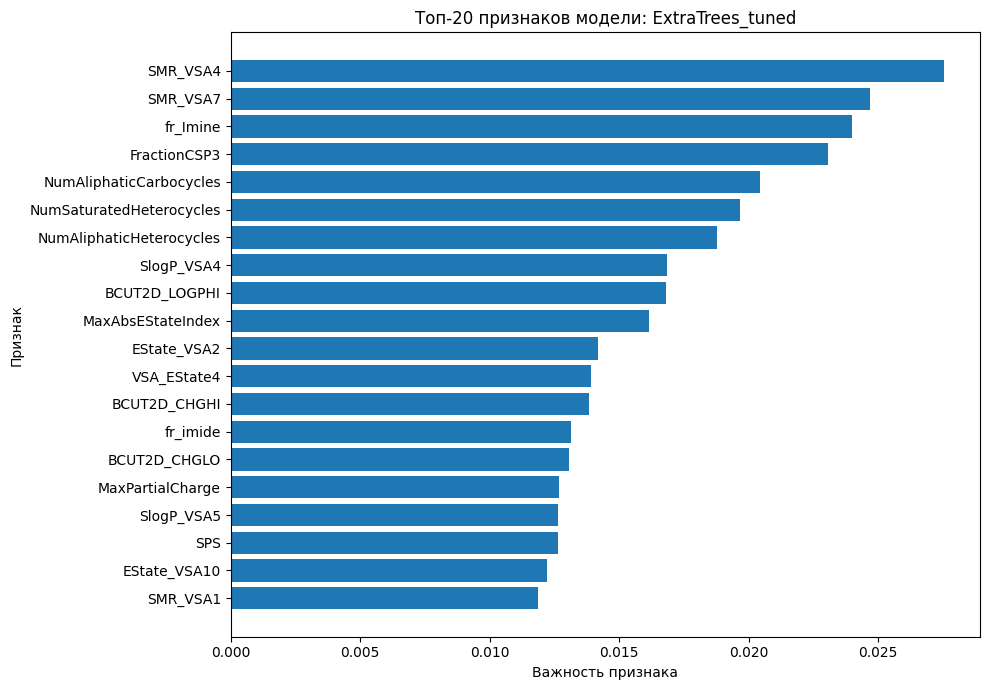

In [ ]:
feature_names_best = X_linear.columns if best_feature_set == 'X_linear' else X_tree.columns

final_model = best_model[-1] if isinstance(best_model, Pipeline) else best_model

def plot_importance(importance_df=None):
    if importance_df is not None:
        display(importance_df.head(30))

        plot_imp = importance_df.head(20).iloc[::-1]

        plt.figure(figsize=(10, 7))
        plt.barh(plot_imp['feature'], plot_imp['importance'])
        plt.xlabel('Важность признака')
        plt.ylabel('Признак')
        plt.title(f'Топ-20 признаков модели: {best_model_name}')
        plt.tight_layout()
        plt.show()
    else:
        print('Для выбранной модели нет встроенной важности признаков или коэффициентов.')

importance_df = None

if hasattr(final_model, 'feature_importances_'):
    importance_df = (
        pd.DataFrame({
            'feature': feature_names_best,
            'importance': final_model.feature_importances_
        })
        .sort_values('importance', ascending=False)
        .reset_index(drop=True)
    )

elif hasattr(final_model, 'coef_'):
    importance_df = (
        pd.DataFrame({
            'feature': feature_names_best,
            'coefficient': np.ravel(final_model.coef_)
        })
        .assign(abs_coefficient=lambda x: x['coefficient'].abs())
        .sort_values('abs_coefficient', ascending=False)
        .drop(columns='abs_coefficient')
        .reset_index(drop=True)
    )

plot_importance(importance_df)

## Сохранение модели

In [42]:

os.makedirs(MODELS_DIR, exist_ok=True)

model_path = os.path.join(MODELS_DIR, 'best_SI_gt_median_classification_model.joblib')

joblib.dump(best_model, model_path)

print(f'Лучшая модель сохранена: {model_path}')

Лучшая модель сохранена: models/best_SI_gt_median_classification_model.joblib


## Выводы

В ноутбуке решается задача бинарной классификации: превышает ли значение SI медианное значение выборки. Порог равен median(SI) = 3.9134. Так как порогом является медиана, классы получились идеально сбалансированными: 483 объекта класса 0 и 483 объекта класса 1. Поэтому accuracy, balanced_accuracy и F1 можно интерпретировать без сильного искажения из-за дисбаланса.

Для сравнения используются две группы моделей: линейные модели на X_linear и tree-based модели на X_tree. Основная метрика -- ROC_AUC, дополнительно анализируются F1 и PR_AUC.

### Сравнение моделей

Результаты для SI > median оказались слабее, чем для IC50 и CC50: лучший CV ROC_AUC составил 0.716 против 0.784 и 0.842 соответственно. Это ожидаемо -- SI = CC50 / IC50 является производной величиной с более сложной и шумной связью с молекулярными дескрипторами.

Примечательно, что SVC_rbf на X_linear показал лучший CV ROC_AUC (0.716) и на тесте (0.751) -- для SI линейный подход в пространстве X_linear оказался конкурентоспособнее tree-based моделей. Это указывает на то, что граница решений для SI > median частично линейна в пространстве RDKit-дескрипторов после VIF-редукции.

После тюнинга лучшей моделью по ROC_AUC стала ExtraTrees_tuned (0.754), однако её преимущество над SVC_rbf baseline минимально: 0.754 против 0.751. При этом SVC_rbf превосходит ExtraTrees_tuned по PR_AUC (0.771 против 0.752) и F1 (0.687 против 0.659). Для задачи поиска селективных соединений PR_AUC практически значимее ROC_AUC, поскольку оценивает качество при акценте на точность нахождения положительного класса. В этом смысле SVC_rbf является равноценной альтернативой финальной модели.

### Анализ матрицы ошибок

Модель демонстрирует асимметрию ошибок: 39 ложноотрицательных (FN) против 21 ложноположительного (FP). Recall класса 1 (SI > median) = 0.598, класса 0 = 0.784 -- модель систематически занижает класс селективных соединений.

С точки зрения практического применения FN-ошибка обходится дороже FP-ошибки: пропустить потенциально селективное соединение означает исключить его из дальнейшего исследования, тогда как ложное включение неселективного соединения лишь добавляет лишний эксперимент. При необходимости снизить FN можно понизить порог классификации с 0.5 до 0.35--0.40, что увеличит Recall класса 1 за счёт снижения Precision.

### Важность признаков

Топ-признаки ExtraTrees_tuned -- SMR_VSA4 (0.028) и SMR_VSA7 (0.025) -- дескрипторы на основе молярной рефракции, характеризующей поляризуемость молекулы. Это принципиально отличается от топ-признаков IC50 и CC50, где доминировали fr_NH2 и NHOHCount (реакционноспособные группы). FractionCSP3 (0.023) и NumAliphaticCarbocycles (0.020) отражают насыщенность и алифатичность молекулы -- свойства, которые одновременно влияют и на активность и на токсичность, определяя тем самым их соотношение SI.

### Рекомендации

- Рассмотреть SVC_rbf как финальную модель для задач где важнее PR_AUC и F1, а не ROC_AUC;
- При необходимости снизить пропуск селективных соединений -- понизить порог классификации до 0.35--0.40;
- Предсказание SI > median через отдельные модели IC50 и CC50 может дать лучший результат, чем прямая классификация по SI.